# Neural Network from Scratch using NumPy

This project implements a fully connected neural network from scratch without using deep learning frameworks like TensorFlow or PyTorch.

## Features:
- Forward Propagation
- Backpropagation
- Adam Optimizer
- Mini-batch Training
- Accuracy, Precision, Recall, F1 Score
- Confusion Matrix Visualization

Importing libery

In [ ]:
import numpy as np
from tensorflow.keras import datasets

## Dataset

- Dataset used: MNIST (handwritten digits)
- Input size: 28x28 images flattened to 784
- Output: 10 classes (digits 0–9)

In [2]:
(X_train, Y_train) , (X_test, Y_test) = datasets.mnist.load_data()

Data Preprocessing

In [3]:
x_train=X_train.reshape(60000,784)
x_test=X_test.reshape(10000,784)

In [18]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [4]:
x_train=x_train/255
x_test=x_test/255

In [5]:
y_train=np.zeros([len(Y_train),10])
y_test=np.zeros([len(Y_test),10])

In [6]:
for i in range(len(Y_train)):
  y_train[i][Y_train[i]]=1
for i in range(len(Y_test)):
  y_test[i][Y_test[i]]=1

In [17]:
print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


## Model Architecture

- Input Layer: 784 neurons
- Hidden Layer 1: 128 neurons (ReLU)
- Hidden Layer 2: 64 neurons (ReLU)
- Output Layer: 10 neurons (Softmax)

Activation Functions

In [7]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return x > 0

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)  # stability
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

Loss Function

In [8]:
def categorical_crossentropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

Weight Initialization

In [9]:
def initialize():
    np.random.seed(42)

    W1 = np.random.randn(784, 128) * np.sqrt(2/784)
    b1 = np.zeros((1, 128))

    W2 = np.random.randn(128, 64) * np.sqrt(2/128)
    b2 = np.zeros((1, 64))

    W3 = np.random.randn(64, 10) * np.sqrt(2/64)
    b3 = np.zeros((1, 10))

    return [W1, b1, W2, b2, W3, b3]

Forward Propagation

In [10]:
def forward(X, params):
    W1, b1, W2, b2, W3, b3 = params

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    cache = (Z1, A1, Z2, A2, Z3, A3)
    return A3, cache

Backward Propagation

In [11]:
def backward(X, y, cache, params):
    W1, b1, W2, b2, W3, b3 = params
    Z1, A1, Z2, A2, Z3, A3 = cache
    m = X.shape[0]

    dZ3 = A3 - y
    dW3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return [dW1, db1, dW2, db2, dW3, db3]

Adam Optimizer Initialization

In [12]:
def adam_update(params, grads, m, v, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    new_params = []

    for i in range(len(params)):
        m[i] = beta1 * m[i] + (1 - beta1) * grads[i]
        v[i] = beta2 * v[i] + (1 - beta2) * (grads[i] ** 2)

        m_hat = m[i] / (1 - beta1 ** t)
        v_hat = v[i] / (1 - beta2 ** t)

        param = params[i] - lr * m_hat / (np.sqrt(v_hat) + eps)
        new_params.append(param)

    return new_params, m, v

In [13]:
def adam_init(params):
    m = [np.zeros_like(p) for p in params]
    v = [np.zeros_like(p) for p in params]
    return m, v

Mini-batch Generator

In [14]:
def get_batches(X, y, batch_size):
    indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
        batch_idx = indices[i:i+batch_size]
        yield X[batch_idx], y[batch_idx]

Training Function

In [15]:
def train(X, y, epochs=10, lr=0.001, batch_size=32):
    params = initialize()
    m, v = adam_init(params)
    t = 0

    for epoch in range(1, epochs + 1):
        epoch_loss = 0
        epoch_acc = 0
        batches = 0

        for X_batch, y_batch in get_batches(X, y, batch_size):
            t += 1

            # Forward
            y_pred, cache = forward(X_batch, params)

            # Loss
            loss = categorical_crossentropy(y_batch, y_pred)

            # Accuracy
            preds = np.argmax(y_pred, axis=1)
            labels = np.argmax(y_batch, axis=1)
            acc = np.mean(preds == labels)

            # Backward
            grads = backward(X_batch, y_batch, cache, params)

            # Update
            params, m, v = adam_update(params, grads, m, v, t, lr)

            epoch_loss += loss
            epoch_acc += acc
            batches += 1

        print(f"Epoch {epoch} | Loss: {epoch_loss/batches:.4f} | Accuracy: {epoch_acc/batches:.4f}")

    return params

## Training Details

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Batch Size: 32
- Epochs: 10

In [16]:
params = train(x_train, y_train)

Epoch 1 | Loss: 0.2349 | Accuracy: 0.9311
Epoch 2 | Loss: 0.1027 | Accuracy: 0.9690
Epoch 3 | Loss: 0.0743 | Accuracy: 0.9780
Epoch 4 | Loss: 0.0549 | Accuracy: 0.9822
Epoch 5 | Loss: 0.0450 | Accuracy: 0.9857
Epoch 6 | Loss: 0.0365 | Accuracy: 0.9882
Epoch 7 | Loss: 0.0311 | Accuracy: 0.9890
Epoch 8 | Loss: 0.0266 | Accuracy: 0.9912
Epoch 9 | Loss: 0.0224 | Accuracy: 0.9927
Epoch 10 | Loss: 0.0209 | Accuracy: 0.9933


Prediction

In [28]:
y_pred, _ = forward(x_test, params)

Accuracy Function

In [29]:
def accuracy(y_pred,y):
    preds = np.argmax(y_pred, axis=1)
    labels = np.argmax(y_test, axis=1)
    acc = np.mean(preds == labels)
    return acc

Accuracy

In [30]:
acc = accuracy(y_pred, y_test)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9765


F1 Score

In [33]:
def classification_metrics(y_true, y_pred, num_classes=10):
    
    y_true = np.argmax(y_true, axis=1)
    y_pred = np.argmax(y_pred, axis=1)
    
    precision_list = []
    recall_list = []
    f1_list = []
    
    for c in range(num_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        
        print(f"Class {c}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")
    
    print("\n--- Overall (Macro Average) ---")
    print(f"Precision: {np.mean(precision_list):.4f}")
    print(f"Recall:    {np.mean(recall_list):.4f}")
    print(f"F1 Score:  {np.mean(f1_list):.4f}")
    
    return precision_list, recall_list, f1_list

In [34]:
precision, recall, f1 = classification_metrics(y_test, y_pred)

Class 0: Precision=0.9750, Recall=0.9939, F1=0.9843
Class 1: Precision=0.9938, Recall=0.9859, F1=0.9898
Class 2: Precision=0.9667, Recall=0.9855, F1=0.9760
Class 3: Precision=0.9668, Recall=0.9792, F1=0.9729
Class 4: Precision=0.9833, Recall=0.9613, F1=0.9722
Class 5: Precision=0.9829, Recall=0.9686, F1=0.9757
Class 6: Precision=0.9762, Recall=0.9864, F1=0.9813
Class 7: Precision=0.9691, Recall=0.9767, F1=0.9729
Class 8: Precision=0.9752, Recall=0.9671, F1=0.9711
Class 9: Precision=0.9758, Recall=0.9584, F1=0.9670

--- Overall (Macro Average) ---
Precision: 0.9765
Recall:    0.9763
F1 Score:  0.9763


Confusion Matrix

In [22]:
def confusion_matrix(y_true, y_pred, num_classes=10):
    y_true = np.argmax(y_true, axis=1)
    y_pred = np.argmax(y_pred, axis=1)
    
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    
    return cm

In [35]:
cm = confusion_matrix(y_test, y_pred)

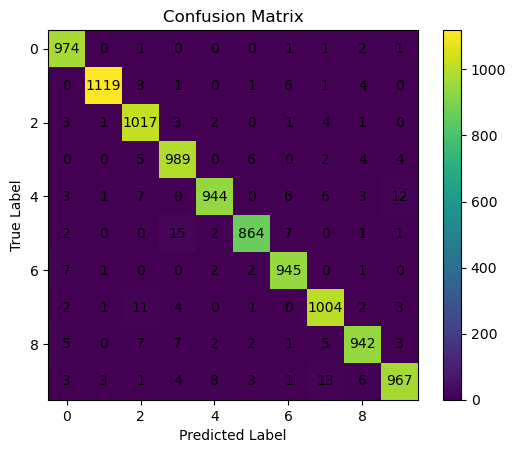

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()    
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
    
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
    
plt.show()